In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
print("all libraries imported successfully")


all libraries imported successfully


In [10]:
data={
     "Age": [20, 22, 25, 28, 30, 35, 40, 45, 50, 55],
    "Income": [20, 25, 30, 35, 40, 45, 50, 60, 70, 80],
    "Buy": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
df

,Age,Income,Buy
0,20,20,0
1,22,25,0
2,25,30,0
3,28,35,0
4,30,40,1
5,35,45,1
6,40,50,1
7,45,60,1
8,50,70,1
9,55,80,1


In [11]:
X= df[["Age","Income"]]
Y= df["Buy"]

In [12]:
X_train, X_test,Y_train,Y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = KNeighborsClassifier(n_neighbors=3)

In [16]:
model.fit(X_train,Y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
prediction= model.predict(X_test)

print("predictions", prediction[0])
print("actual", Y_test.values)


predictions 1
actual [1 0]


In [21]:
accuracy = accuracy_score(Y_test, prediction )

print("accuracy :", accuracy )

accuracy : 1.0


In [22]:
cm= confusion_matrix(Y_test, prediction)

print("confusion matrix ", cm)

confusion matrix  [[1 0]
 [0 1]]


In [23]:
customer =[[32, 42]]

customer_scaled= scaler.transform(customer)

result = model.predict(customer_scaled)

if (result[0]==1):
    print("customer will buy")
else:
    print("customer will not buy")
    


customer will buy


C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


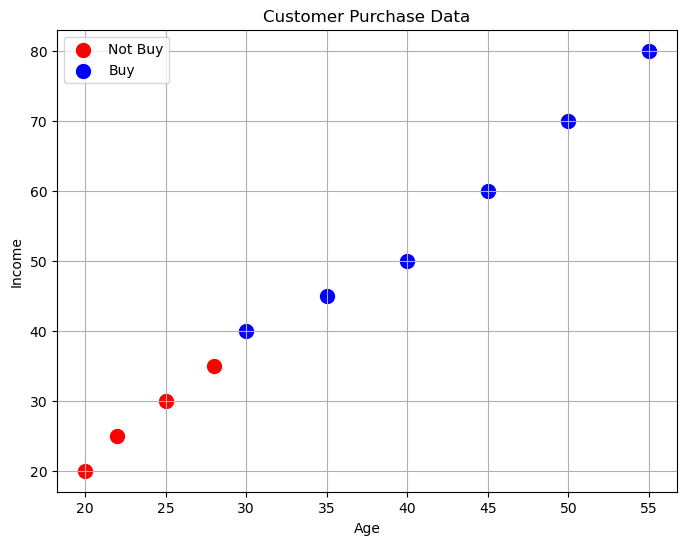

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Buy"] == 0]["Age"],
    df[df["Buy"] == 0]["Income"],
    color="red",
    label="Not Buy",
    s=100
)

plt.scatter(
    df[df["Buy"] == 1]["Age"],
    df[df["Buy"] == 1]["Income"],
    color="blue",
    label="Buy",
    s=100
)

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Customer Purchase Data")
plt.legend()
plt.grid(True)

plt.show()